# 04 · Recover waste heat with a heat pump

Build a plain-data performance map and choose heat-pump investment to meet a 150 kW heating duty.

Use Python 3.14.2 or newer. In a terminal, run `python -m pip install "OpenUtility[notebook]>=0.1.2"`, then `python -m jupyterlab`. Select that environment's Python kernel and choose **Restart Kernel and Run All Cells**. No repository checkout, external files, credentials, or commercial solver is needed; HiGHS comes with OpenUtility. All data and prices below are synthetic, in arbitrary currency units (CU).

In [1]:
from dataclasses import asdict
from importlib.metadata import version
import math
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import OpenUtility as ou
from IPython.display import display

print(f"OpenUtility {version('OpenUtility')}")
plt.rcParams.update(
    {"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False}
)
solve = ou.pyomo_utility_system_solver("appsi_highs")

OpenUtility 0.1.2


## Define a synthetic performance map

At 40°C source and 80°C sink, a heating COP of 3 gives 150 kW delivered heat from 100 kW source heat and 50 kW electricity. The two part-load points share one temperature curve. OpenUtility interpolates the supplied data; it does not calculate these thermodynamic performance values.

In [2]:
# The current schema requires a steam level, even for electricity/HPR examples.
# This zero-duty placeholder contributes no heat, steam, or cost.
level = ou.SteamLevelCandidate(
    name="MP_100",
    steam_main="MP",
    temperature=100.0,
    source_heat_available=0.0,
    sink_heat_demand=0.0,
    generation_enthalpy_delta=1.0,
    use_enthalpy_delta=1.0,
)

performance = ou.HprPerformanceMap(
    schema_version="1.0",
    map_id="tutorial-map",
    mode="heat_pump",
    units={
        "source_temperature": "degC",
        "sink_temperature": "degC",
        "q_source": "kW",
        "q_sink": "kW",
        "electric_power": "kW",
    },
    reference_capacity=150.0,
    reference_capacity_basis="q_sink",
    interpolation_topology="ordered_part_load_curve",
    thermodynamic_backend="synthetic",
    model_id="constant-cop",
    provenance={
        "source": "OpenUtility public tutorial; synthetic energy-balanced data"
    },
    cop_convention="heating",
    points=tuple(
        ou.HprPerformancePoint(
            name=f"load-{fraction}",
            curve_id="fixed-temperatures",
            source_temperature=40.0,
            sink_temperature=80.0,
            load_fraction=fraction,
            q_source=100.0 * fraction,
            q_sink=150.0 * fraction,
            electric_power=50.0 * fraction,
        )
        for fraction in (0.5, 1.0)
    ),
)
display(pd.DataFrame([asdict(point) for point in performance.points]))

,name,curve_id,source_temperature,sink_temperature,load_fraction,q_source,q_sink,electric_power,cop
0,load-0.5,fixed-temperatures,40.0,80.0,0.5,50.0,75.0,25.0,None
1,load-1.0,fixed-temperatures,40.0,80.0,1.0,100.0,150.0,50.0,None


## Connect source, sink, and investment

Electricity costs 0.15 CU/kWh; backup heating costs 0.08 CU/kWh. The heat pump costs 40,000 CU with 10% annualization. Period hours determine HPR energy costs directly: do not multiply them again by static `operating_hours`. The static electricity subsystem is idle in this example.

,Source recovered (kW),Heat delivered (kW),Electricity (kW),Heating COP,Annual cost (CU/year)
0,100.0,150.0,50.0,3.0,34000.0


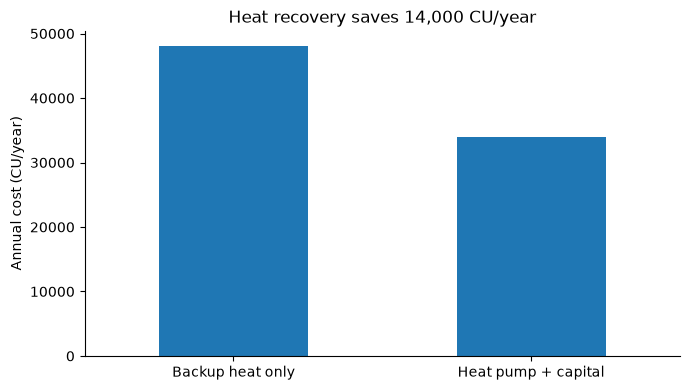

In [3]:
data = ou.UtilitySystemModelData(
    steam_mains=("MP",),
    steam_levels=(level,),
    power_demand=0.0,
    grid_import_limit=0.0,
    grid_export_limit=0.0,
    thermal_nodes=(
        ou.ThermalNode("waste", 40.0, "source"),
        ou.ThermalNode("heat", 80.0, "sink", heating_unit_cost=0.08),
    ),
    periods=(
        ou.OperatingPeriod(
            name="production",
            hours=4000.0,
            electricity_import_unit_cost=0.15,
            source_heat_available={"waste": 100.0},
            heating_demand={"heat": 150.0},
        ),
    ),
    hpr_performance_maps=(performance,),
    hpr_candidates=(
        ou.HprCandidate(
            name="HP",
            mode="heat_pump",
            map_id="tutorial-map",
            source_node="waste",
            sink_node="heat",
            fixed_capacity=150.0,
        ),
    ),
    equipment_costs=(
        ou.EquipmentCost(
            name="HP investment",
            equipment_type="hpr",
            equipment_name="HP",
            annualization_factor=0.1,
            installation_factor=1.0,
            variable_capital_cost=0.0,
            fixed_capital_cost=40000.0,
        ),
    ),
)
model = ou.build_utility_system_model(data)
status = solve(model)
assert status.termination_condition == "optimal", status
source = pyo.value(model.hpr_q_source["HP", "production"])
sink = pyo.value(model.hpr_q_sink["HP", "production"])
power = pyo.value(model.hpr_power["HP", "production"])
assert pyo.value(model.hpr_selected["HP"]) > 0.5
assert math.isclose(sink, 150.0, abs_tol=1e-6)
assert math.isclose(sink, source + power, abs_tol=1e-6)
assert math.isclose(sink / power, 3.0, abs_tol=1e-6)
assert math.isclose(pyo.value(model.total_annualized_cost), 34000.0, abs_tol=1e-6)
display(
    pd.DataFrame(
        [
            {
                "Source recovered (kW)": source,
                "Heat delivered (kW)": sink,
                "Electricity (kW)": power,
                "Heating COP": sink / power,
                "Annual cost (CU/year)": pyo.value(model.total_annualized_cost),
            }
        ]
    )
)
ax = pd.Series({"Backup heat only": 48000.0, "Heat pump + capital": 34000.0}).plot.bar(
    rot=0
)
ax.set(ylabel="Annual cost (CU/year)", title="Heat recovery saves 14,000 CU/year")
plt.tight_layout()
plt.show()

## Try it

Reduce available waste heat to 50 kW. The source balance will limit recovery and backup heating will cover the shortfall. Inspect `node_external_heating["production", "heat"]` and recalculate the expected annual cost before updating the assertion.